In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
plt.style.use('fivethirtyeight')

In [49]:
dataset = sns.load_dataset("tips")
dataset.tail(20)

,total_bill,tip,sex,smoker,day,time,size
224,13.42,1.58,Male,Yes,Fri,Lunch,2
225,16.27,2.50,Female,Yes,Fri,Lunch,2
226,10.09,2.00,Female,Yes,Fri,Lunch,2
227,20.45,3.00,Male,No,Sat,Dinner,4
228,13.28,2.72,Male,No,Sat,Dinner,2
229,22.12,2.88,Female,Yes,Sat,Dinner,2
230,24.01,2.00,Male,Yes,Sat,Dinner,4
231,15.69,3.00,Male,Yes,Sat,Dinner,3
232,11.61,3.39,Male,No,Sat,Dinner,2
233,10.77,1.47,Male,No,Sat,Dinner,2


RELPLOT

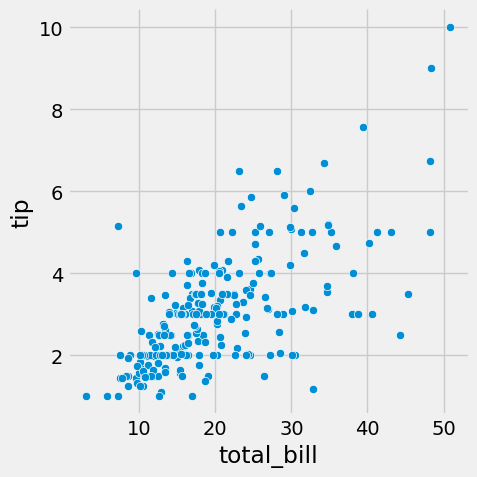

In [50]:
sns.relplot(x="total_bill", y="tip", kind="scatter", data=dataset)

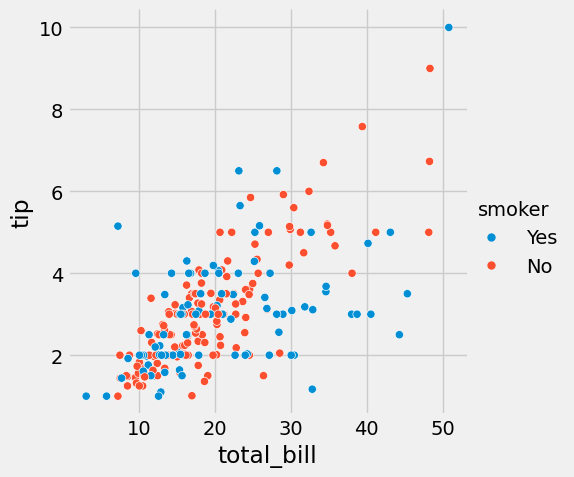

In [ ]:
sns.relplot(x="total_bill", y="tip", hue="smoker", kind="scatter", data=dataset) # hue is used to differentiate between smokers and non-smokers in the scatter plot. hue parameter is used to assign different colors to the points based on the "smoker" variable. This allows us to visually distinguish between smokers and non-smokers in the scatter plot.

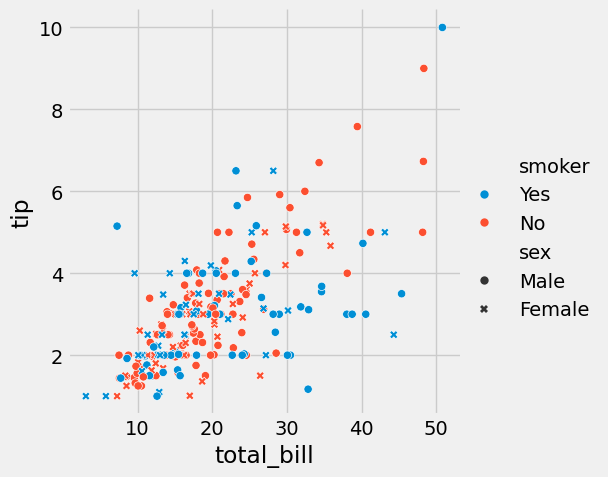

In [ ]:
sns.relplot(x="total_bill", y="tip", hue="smoker", style = "sex", kind="scatter", data=dataset) # style parameter is used to differentiate between male and female customers in the scatter plot. style parameter is used to assign different marker styles to the points based on the "sex" variable

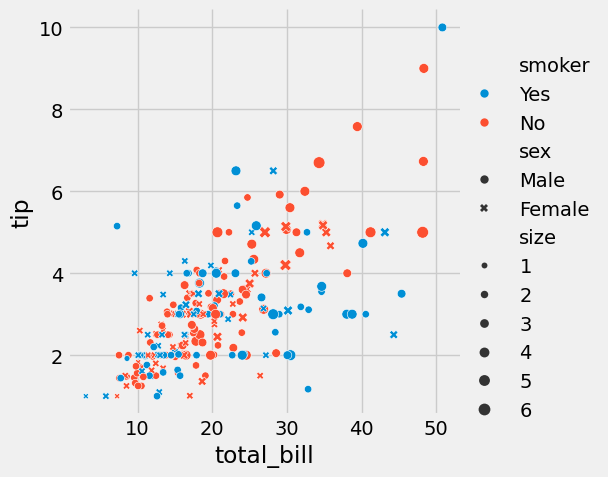

In [15]:
sns.relplot(x="total_bill", y="tip", hue="smoker", style = "sex",size="size", kind="scatter", data=dataset) # size parameter is used to differentiate between different group sizes in the scatter plot. size parameter is used to assign different marker sizes to the points based on the "size" variable. This allows us to visually distinguish between different group sizes in the scatter plot, with larger markers representing larger groups and smaller markers representing smaller groups.

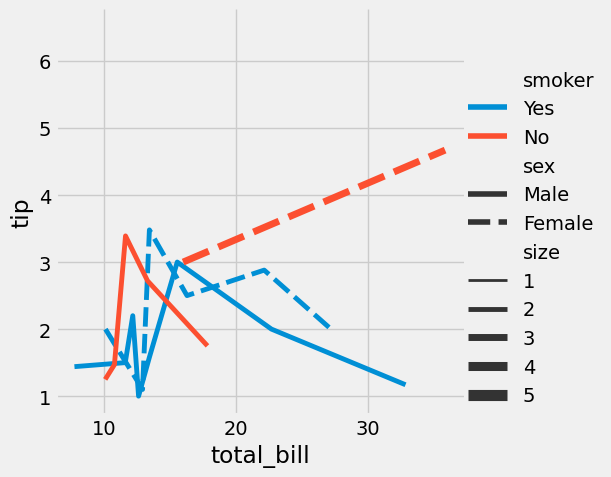

In [17]:
sns.relplot(x="total_bill", y="tip", hue="smoker", style = "sex",size="size", kind="line", data=dataset.tail(30)) 

<Axes: xlabel='total_bill', ylabel='tip'>

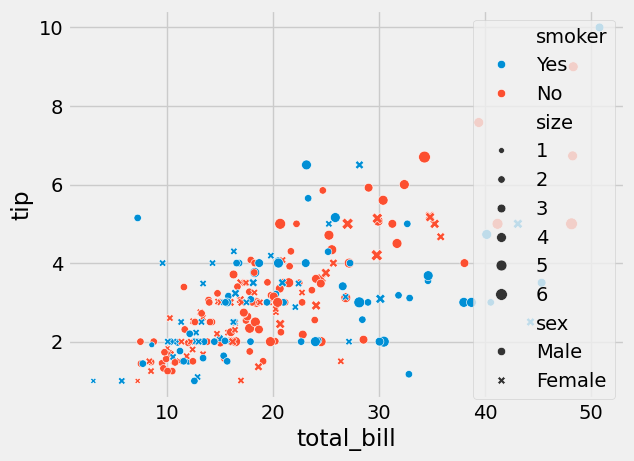

In [9]:
# using scatter plot fumction
sns.scatterplot(x="total_bill", y="tip", hue="smoker", style = "sex",size="size", data=dataset)

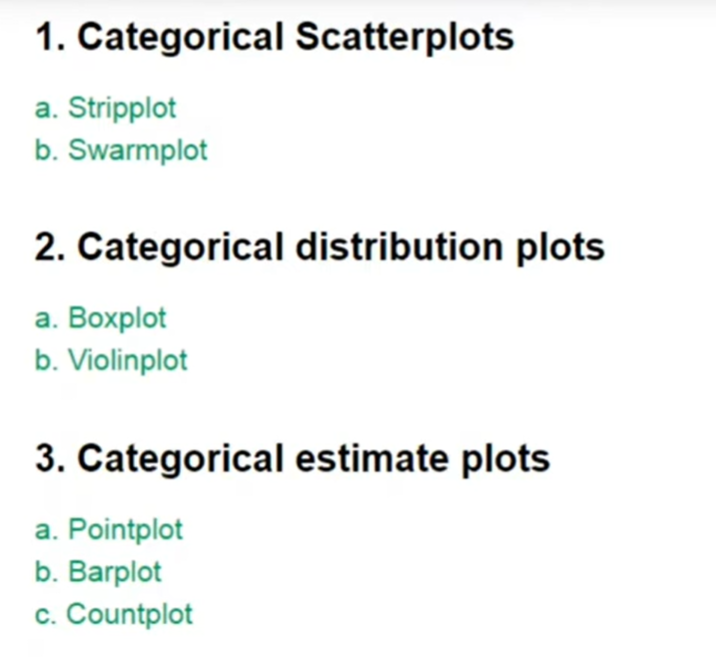

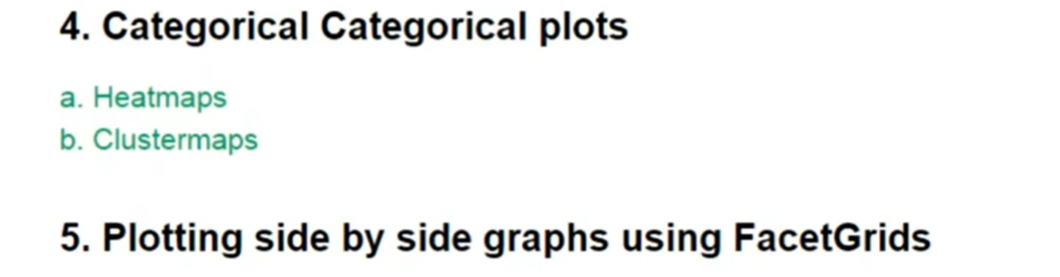

1. CATEGORICAL SCATTER PLOT

strip plot

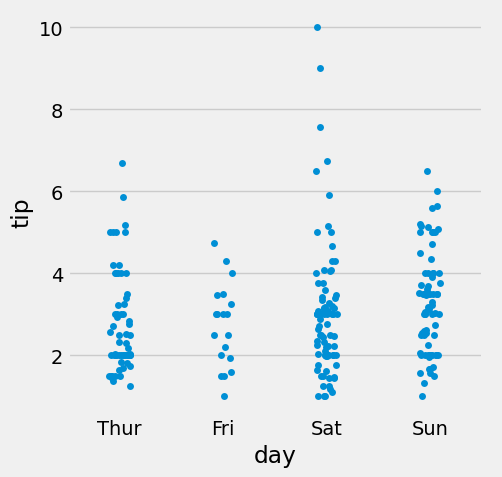

In [38]:
# 1. categorical scatter plot
# x axis catogorical data and y axis numerical data
# sns.catplot(x="day", y="tip",kind="strip", data=dataset)

# it uses jitter which seperates the points to avoid overlap 

sns.catplot(x="day", y="tip",kind="strip",jitter=0.1, data=dataset) 


swarm plot


c:\Users\Meet\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 8.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\Meet\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 6.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


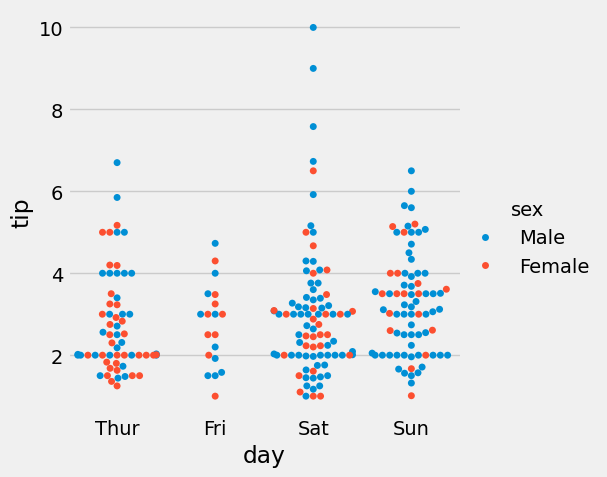

In [ ]:
# sns.catplot(x="day", y="tip", kind = "swarm",data = dataset)
# sns.swarmplot(x="day ", y = "tip", data = dataset)
sns.catplot(x="day", y="tip", kind = "swarm",hue="sex",data = dataset)


2.CATEGORICAL DISTRIBUTION PLOTS

BOXPLOT (finds outliers) IQR

<Axes: ylabel='tip'>

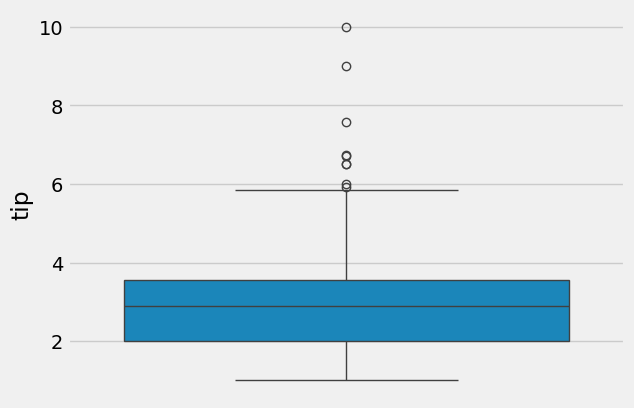

In [52]:
# sns.boxplot(dataset["total_bill"]) 
sns.boxplot(dataset["tip"])

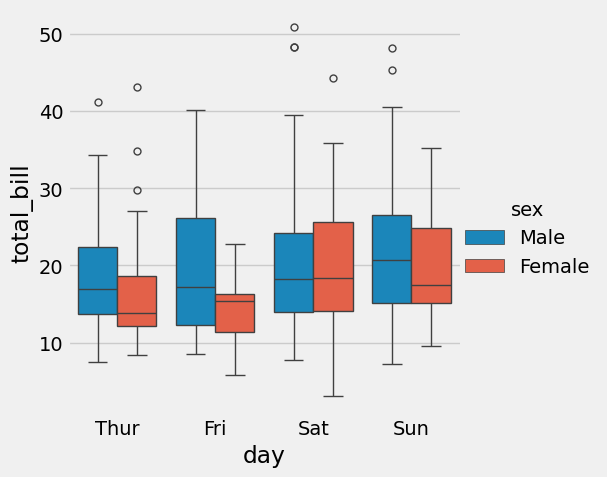

In [56]:
# now multivariate analysis 
# boxplot on total bill wrt different days 

# sns.catplot(x="day", y="total_bill", kind = "box", data = dataset)

sns.catplot(x="day", y="total_bill", kind = "box", hue="sex", data = dataset)

VOILINPLOTS

method of plotting numeric data and can be considered a combination of the boxplot with a kerner density plot(probability density)


<Axes: ylabel='total_bill'>

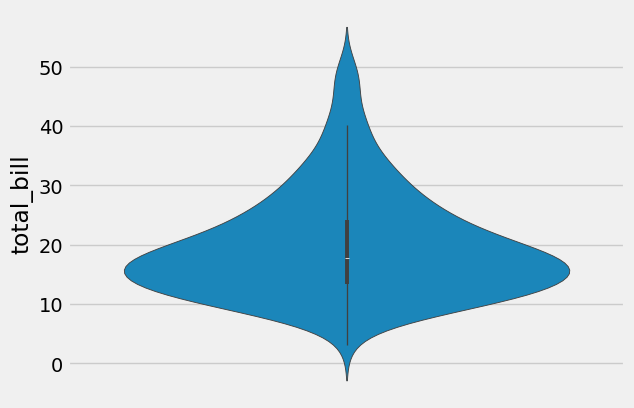

In [ ]:
sns.violinplot(dataset["total_bill"])

# inside there is a box plot and outside it is the probability density of the data

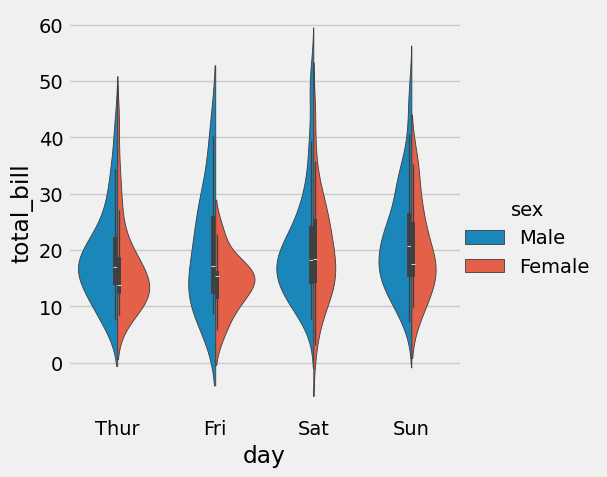

In [60]:
# sns.catplot(x="day", y= "total_bill", kind = "violin", data = dataset)

# ab isme firse hum same chij kar skate h hue parameter
# sns.catplot(x="day", y= "total_bill", kind = "violin", hue="sex", data = dataset)
# ab ye problem arahi hai data bohiot jyada cluttered hai and acha nahi dikh rha toh hum split paramete use krke space bacha skte hai and aur atttractive bana sjkte hai

sns.catplot(x="day", y= "total_bill", kind = "violin", hue="sex", split=True, data = dataset)

3. CATEGORICAL ESTIMATE PLOTS

BARPLOT

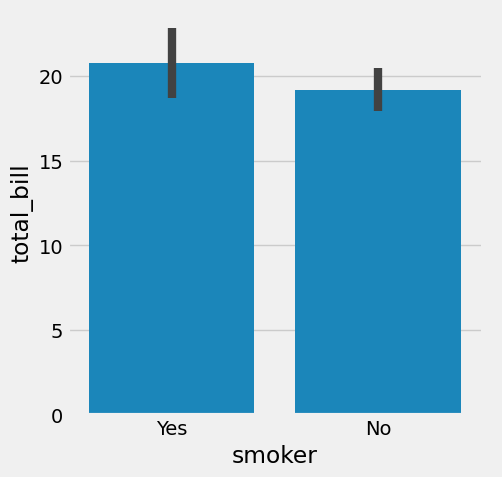

In [ ]:
# mean value of total_bill for smokers and non smokers 

sns.catplot(x = "smoker",y = "total_bill", kind = "bar", data = dataset) # estimator by default = mean

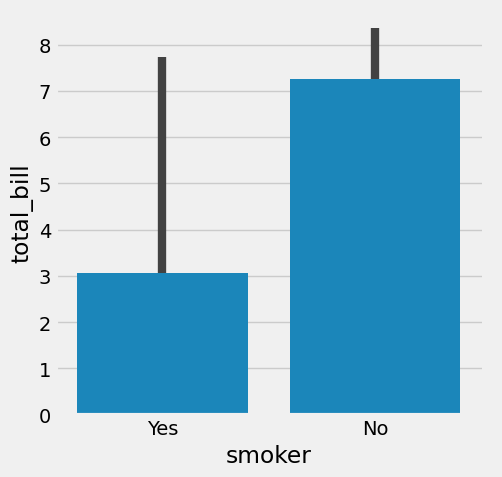

In [73]:
# sns.catplot(x = "smoker", y= "total_bill", kind = "bar", estimator = np.max , data = dataset)

# estimator parameter is used here to represent the maximum value of total_bill for smokers and non-smokers in the bar plot. By setting estimator to np.max, we are instructing the catplot function to calculate and display the maximum total_bill for each category of the "smoker" variable. This allows us to compare the maximum total_bill values between smokers and non-smokers in the bar plot.

sns.catplot(x = "smoker", y= "total_bill", kind = "bar", estimator = np.min , data = dataset)


COUNTPLOT

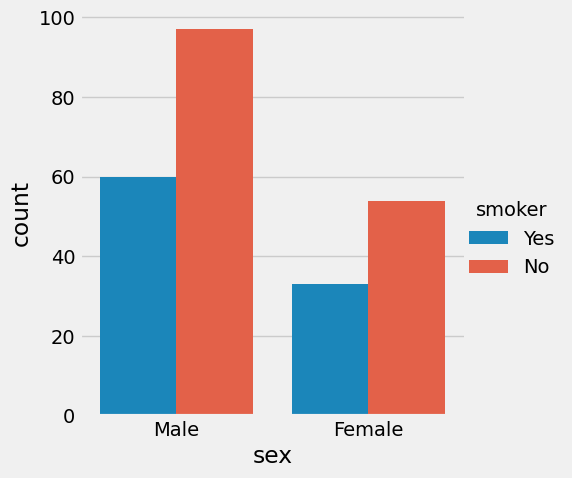

In [75]:
# number of males and females

# sns.catplot(x = "sex", kind = "count", data = dataset)

sns.catplot(x="sex", kind="count",hue = "smoker", data=dataset)

HEATMAPS

In [76]:
flight = sns.load_dataset("flights")
flight.head(20)

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121
5,1949,Jun,135
6,1949,Jul,148
7,1949,Aug,148
8,1949,Sep,136
9,1949,Oct,119


In [80]:
x= flight.pivot_table(index="year", columns="month", values="passengers",aggfunc="sum")
x.head(20)

month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
year,,,,,,,,,,,,
1949,112,118,132,129,121,135,148,148,136,119,104,118
1950,115,126,141,135,125,149,170,170,158,133,114,140
1951,145,150,178,163,172,178,199,199,184,162,146,166
1952,171,180,193,181,183,218,230,242,209,191,172,194
1953,196,196,236,235,229,243,264,272,237,211,180,201
1954,204,188,235,227,234,264,302,293,259,229,203,229
1955,242,233,267,269,270,315,364,347,312,274,237,278
1956,284,277,317,313,318,374,413,405,355,306,271,306
1957,315,301,356,348,355,422,465,467,404,347,305,336


<Axes: xlabel='month', ylabel='year'>

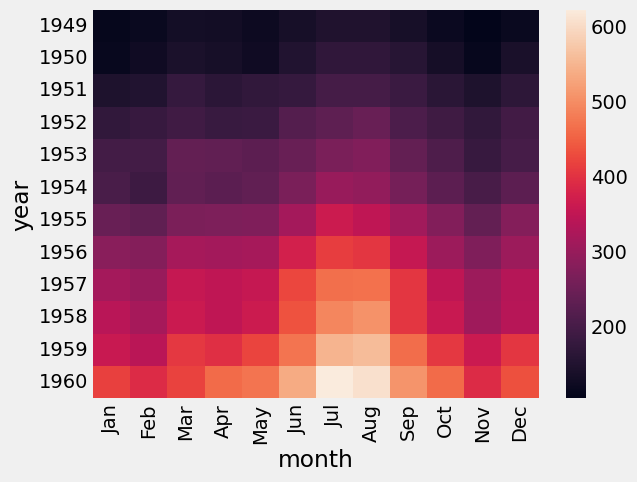

In [81]:
sns.heatmap(x)

<Axes: xlabel='month', ylabel='year'>

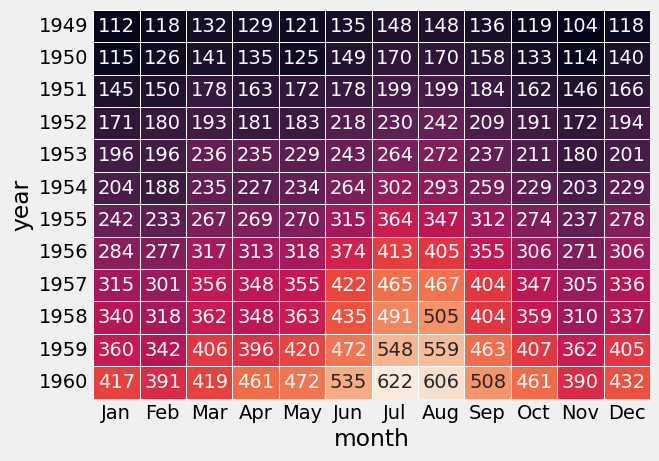

In [85]:
# sns.heatmap(x, cbar = False,linewidths=0.5)

sns.heatmap(x,cbar = False,linewidths=0.5, annot = True , fmt = "d" )

CLUSTERMAP

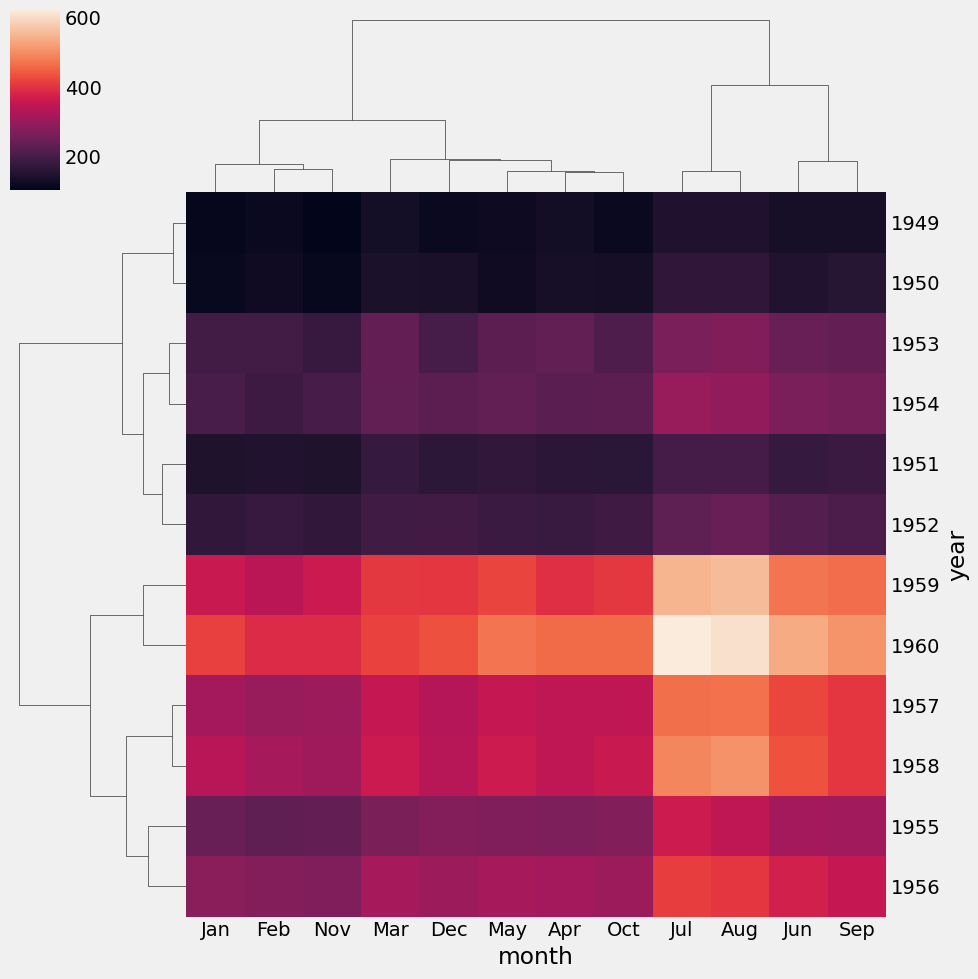

In [86]:
sns.clustermap(x)

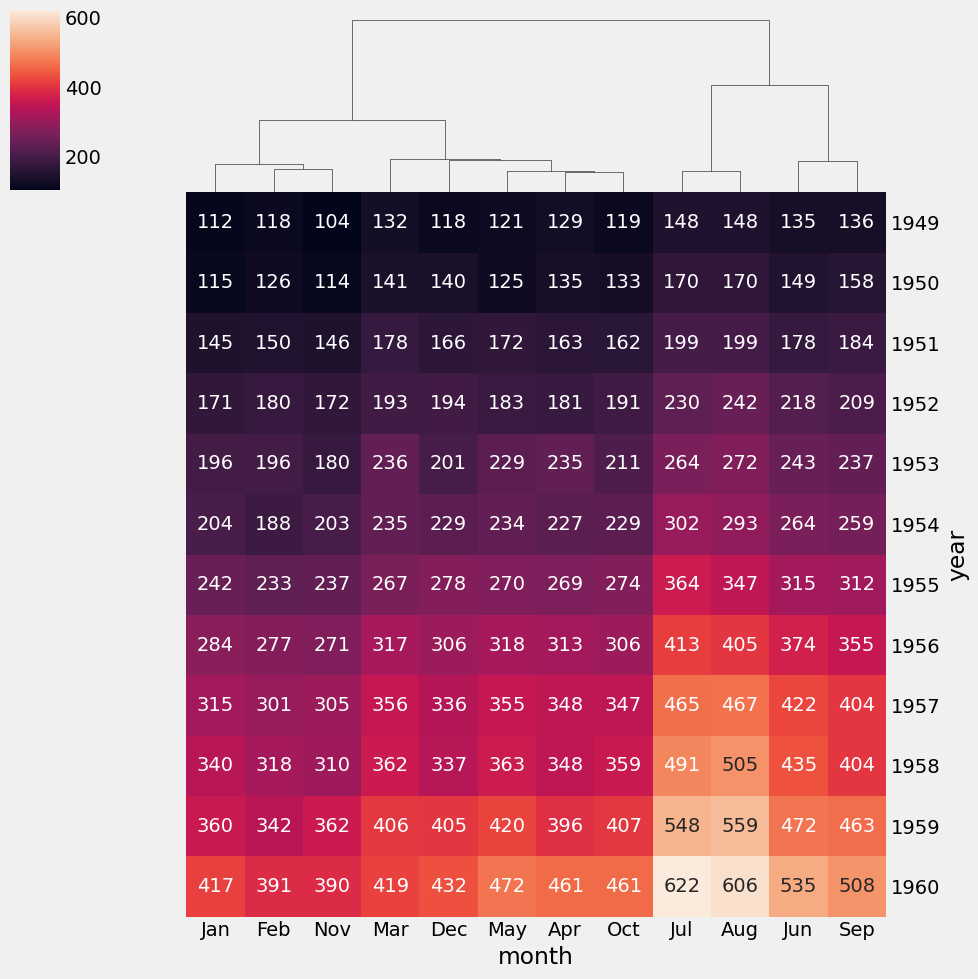

In [ ]:
sns.clustermap(x,annot = True , fmt = "d",row_cluster=False) # metric = "euclidean" is default we can change further from documentation


JOINTPLOT


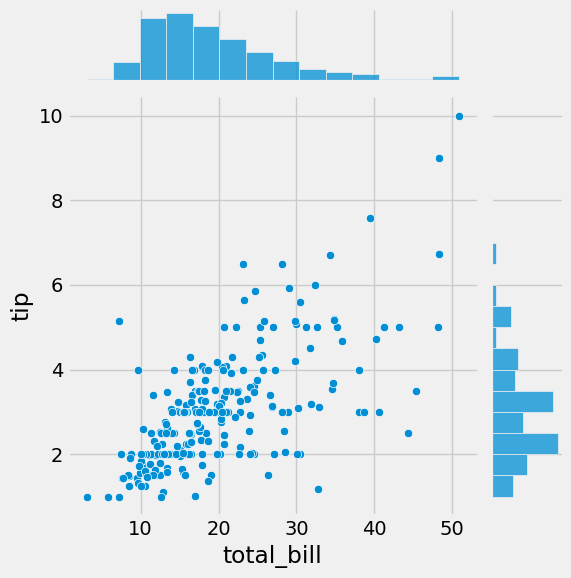

In [ ]:
sns.jointplot(x="total_bill", y="tip", data=dataset) # scatter plot with histograms on the sides (kind = "scatter" is default)

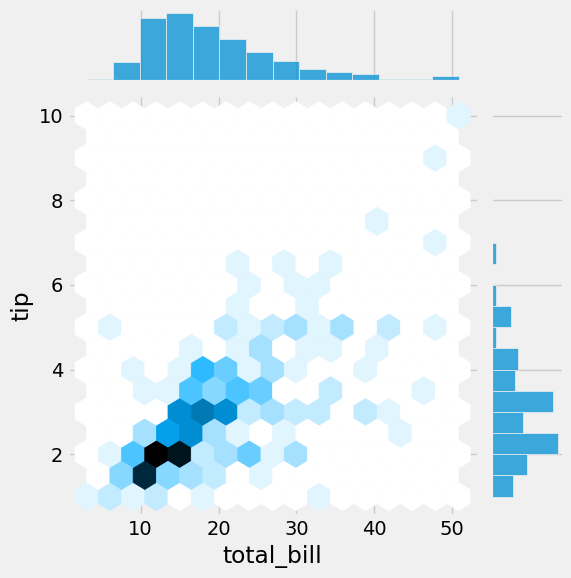

In [ ]:
sns.jointplot(x="total_bill", y="tip", data=dataset , kind = "hex") # hexagonal binning plot is a type of plot that is used to visualize the relationship between two numerical variables. It divides the plot area into hexagonal bins and counts the number of data points that fall into each bin. The color of each bin represents the count of data points in that bin, with darker colors indicating higher counts. This type of plot is particularly useful for visualizing the density of data points in a scatter plot, especially when there are a large number of overlapping points. By using hexagonal bins, it provides a clearer representation of the distribution of data points and helps to identify patterns and trends in the relationship between the two variables.

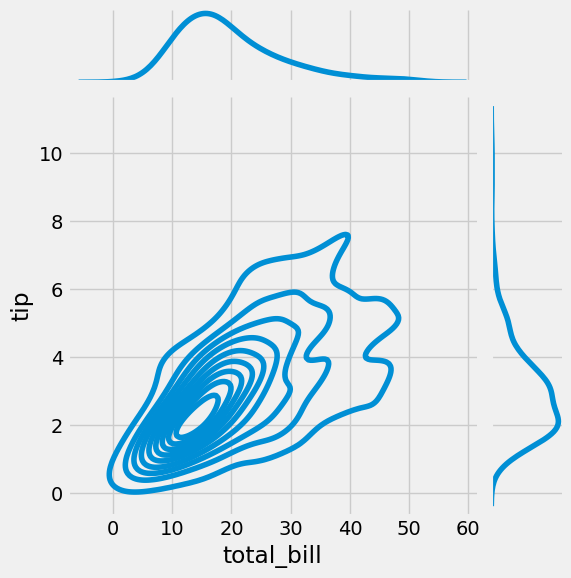

In [ ]:
sns.jointplot(x="total_bill", y="tip",kind = "kde",  data=dataset) # scondur -> kde (probability density function) plot is a type of plot that is used to visualize the distribution of a single variable or the relationship between two variables. It estimates the probability density function of the data using kernel density estimation, which is a non-parametric way to estimate the probability density function of a random variable. In a jointplot with kind="kde", the plot will show the contour lines representing the density of data points in the scatter plot, allowing us to visualize areas of higher and lower concentration of data points. This can help us identify patterns and trends in the relationship between the two variables.
# think of this as moutain
# innermost circle highest(peak of mountain) density of data points and as we move outward density decreases

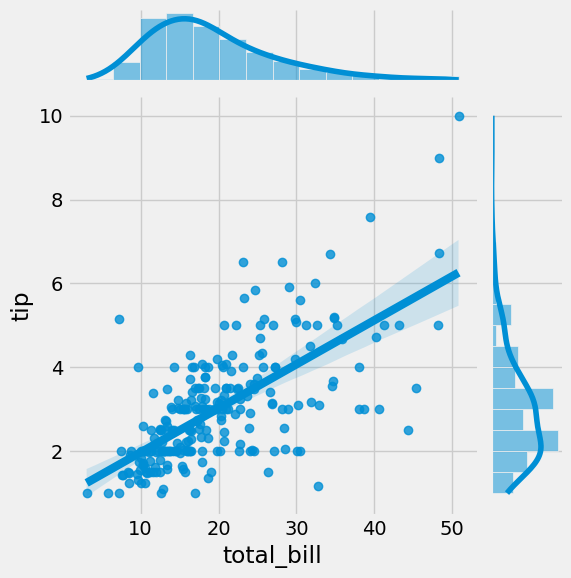

In [ ]:
sns.jointplot(x="total_bill", y="tip",kind= "reg" , data=dataset)
# basically linear regression
# best fit line is plotted on the scatter plot to show the overall trend in the relationship between the two variables. The regression line helps us understand how the total bill amount is related to the tip amount, and it can also be used to make predictions about the tip based on the total bill.

PAIRPLOT

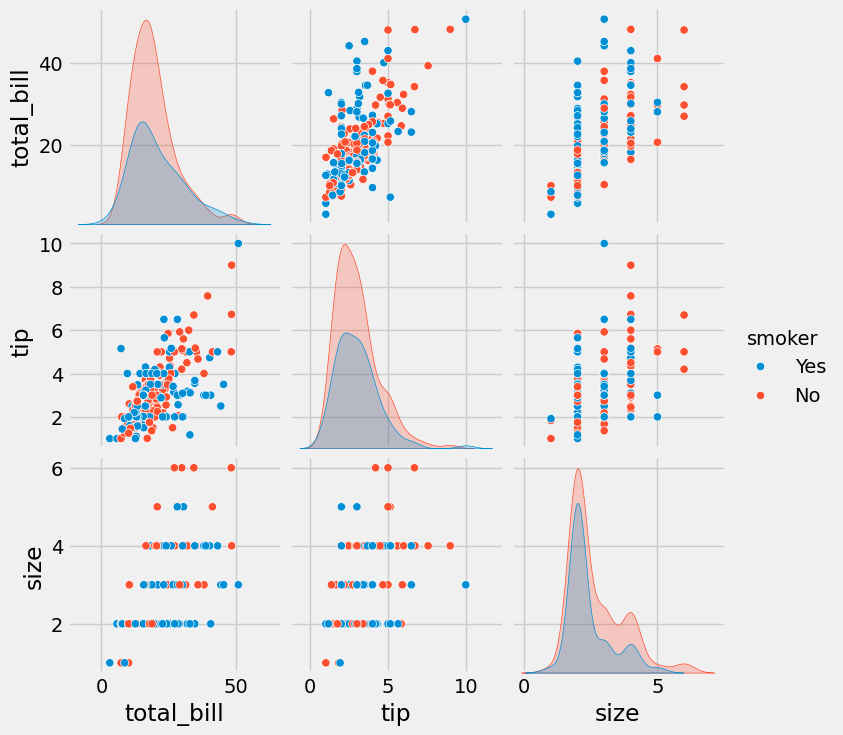

In [102]:
# sns.pairplot(dataset)
sns.pairplot(dataset,hue = "smoker")

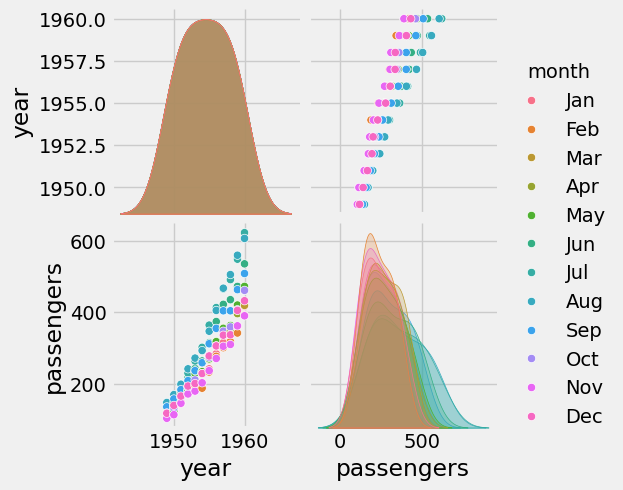

In [101]:
sns.pairplot(flight,hue = "month")

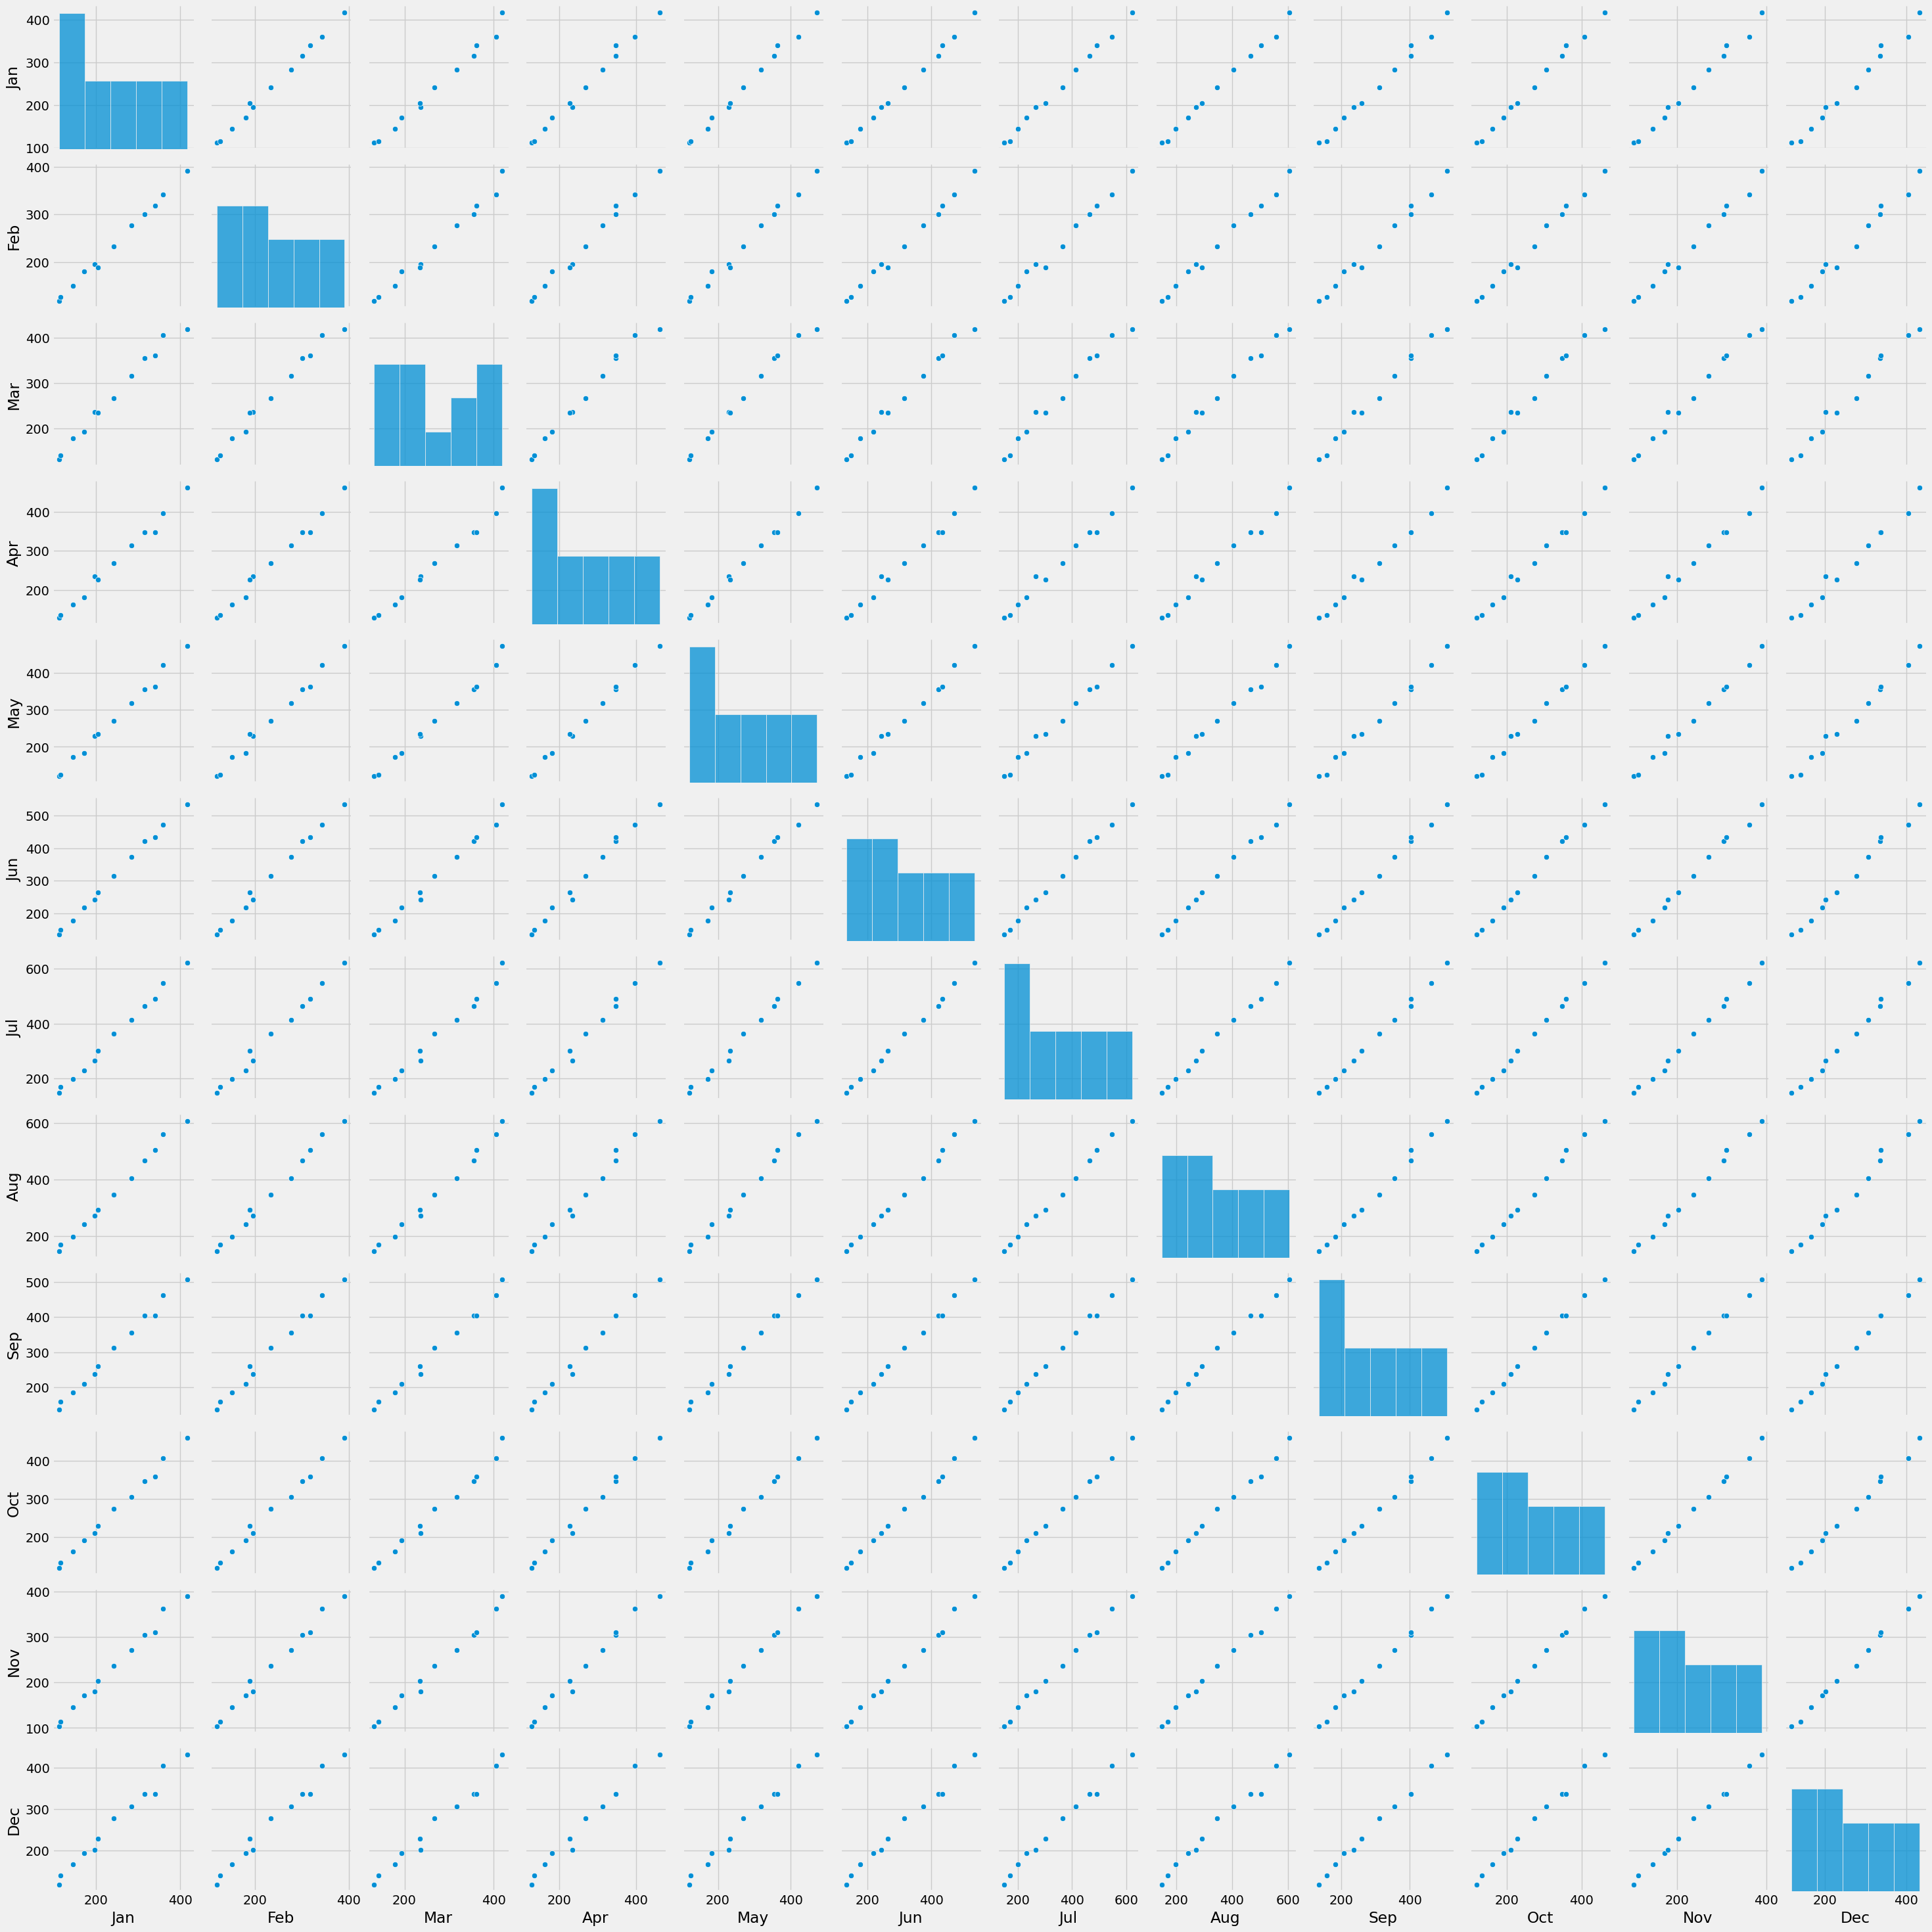

In [100]:
sns.pairplot(x)


In [96]:
iris= sns.load_dataset("iris")
iris.head(20)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


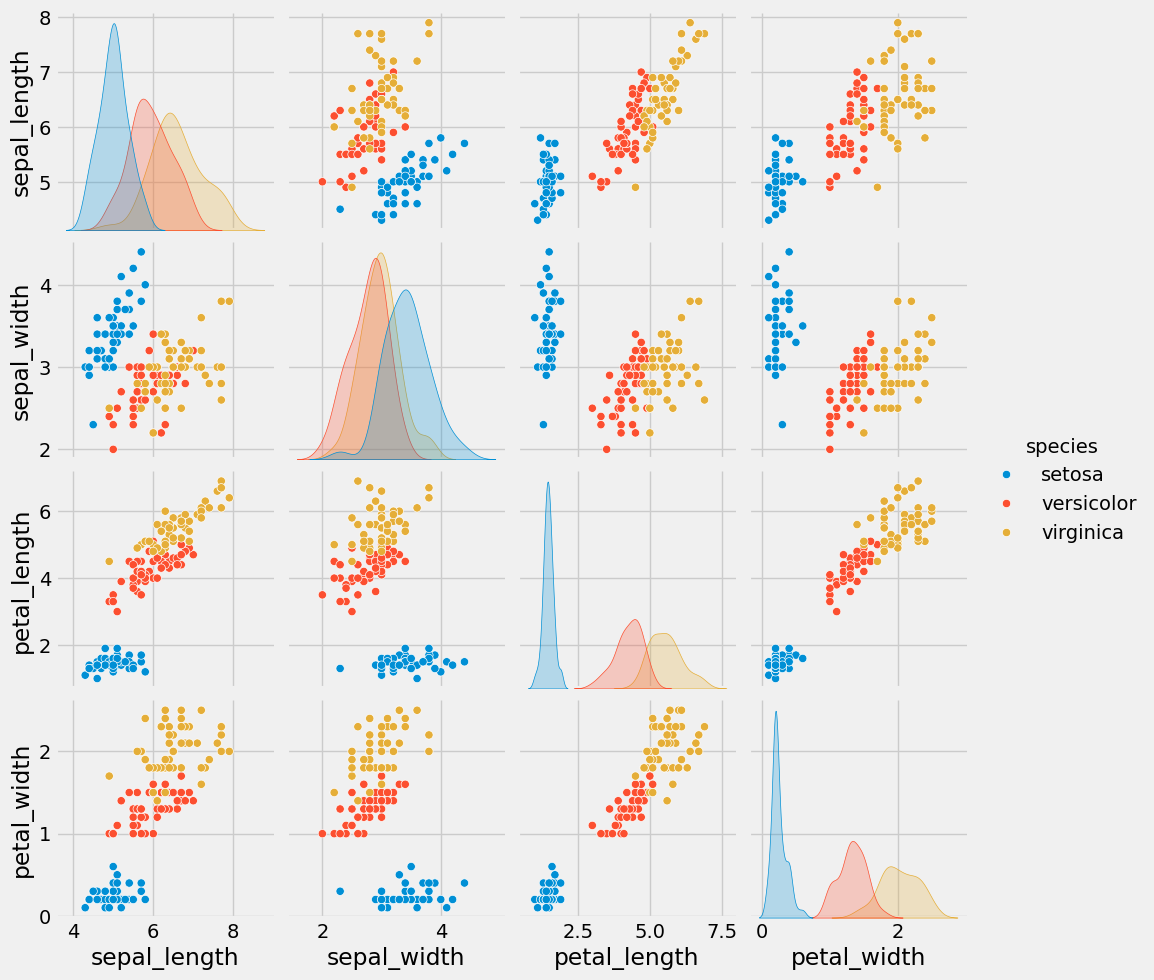

In [98]:
# sns.pairplot(iris)
sns.pairplot(iris, hue = "species")

DISPLOTS

In [103]:
titanic = sns.load_dataset("titanic")
titanic.head(20)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [113]:
titanic['age'].fillna(titanic['age'].mean(), inplace=True)

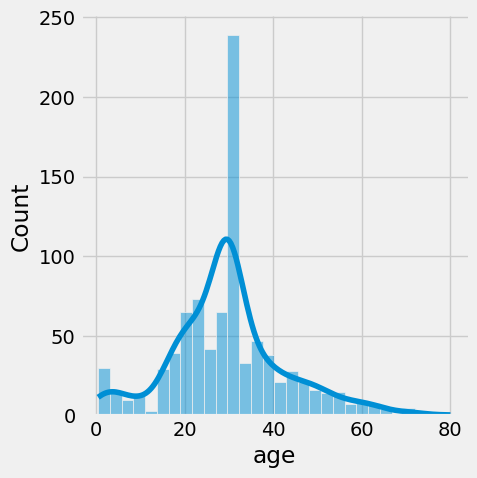

In [117]:
sns.displot(titanic["age"], kde = True) # false if we want to plot only hsitogram and hist = false if only kde
# sns.displot(titanic["age"], kde = True , bins = 10) # bins parameter is used to specify the number of bins to be used in the histogram. By setting bins to 30, we are instructing the displot function to divide the age data into 30 equal-width bins for the histogram. This allows us to visualize the distribution of ages in the titanic dataset with a finer level of detail, as more bins will provide a more granular view of the age distribution.

# sns.displot(titanic['age'], kde = False, hist = False, rug = True) # rug mai extra feature hai jisse pta chlta h values konse side jyada tilt ho rhi h 

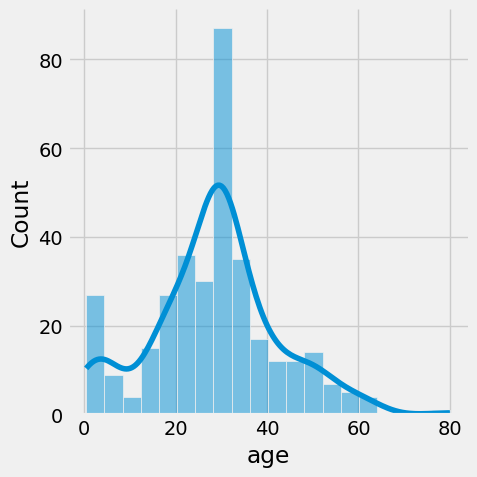

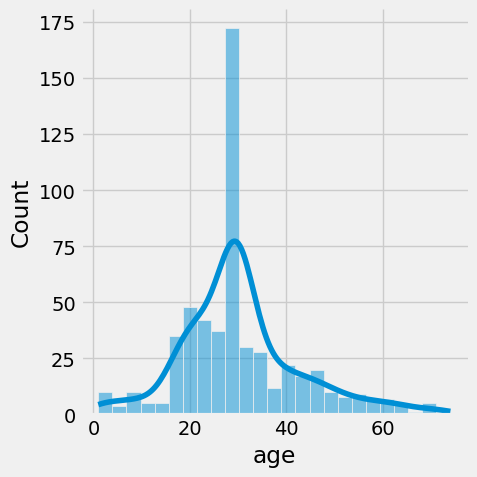

In [ ]:
# who survived titanic
sns.displot(titanic[titanic["survived"] == 1]["age"], kde=True)
sns.displot(titanic[titanic["survived"] == 0]["age"], kde=True)